<a href="https://colab.research.google.com/github/jdcg5299/modelos-ai-portfolio/blob/main/Regresion_Real_State_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from numpy import *
import matplotlib.pyplot as plt

In [ ]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

# fetch dataset
real_estate_valuation = fetch_ucirepo(id=477)

# data (as pandas dataframes)
X = real_estate_valuation.data.features
y = real_estate_valuation.data.targets

# metadata
print(real_estate_valuation.metadata)

# variable information
print(real_estate_valuation.variables)

dataset = real_estate_valuation.data.original
dataset.head()

{'uci_id': 477, 'name': 'Real Estate Valuation', 'repository_url': 'https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set', 'data_url': 'https://archive.ics.uci.edu/static/public/477/data.csv', 'abstract': 'The real estate valuation is a regression problem. The market historical data set of real estate valuation are collected from Sindian Dist., New Taipei City, Taiwan. ', 'area': 'Business', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 414, 'num_features': 6, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Y house price of unit area'], 'index_col': ['No'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2018, 'last_updated': 'Mon Feb 26 2024', 'dataset_doi': '10.24432/C5J30W', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 373, 'type': 'NATIVE', 'title': 'Building real estate valuation models with comparative approach through case-based reasoning', 'authors': 'I. Yeh

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [ ]:

dataset.describe()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148971,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281967,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.917000,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000



--- Resumen Estadístico ---


,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,2013.148971,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,0.281967,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,2012.917000,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


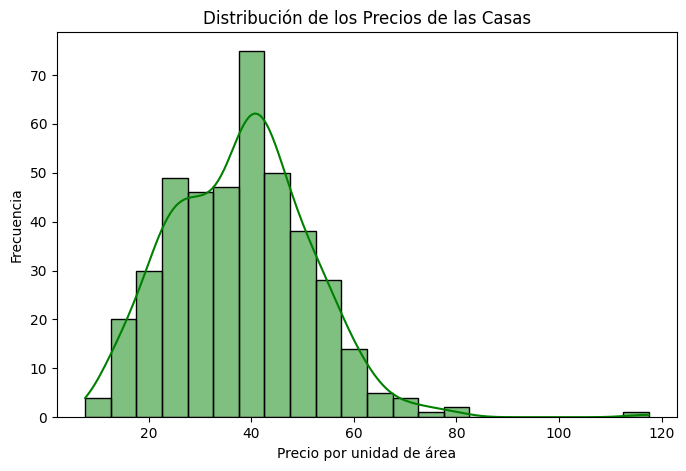

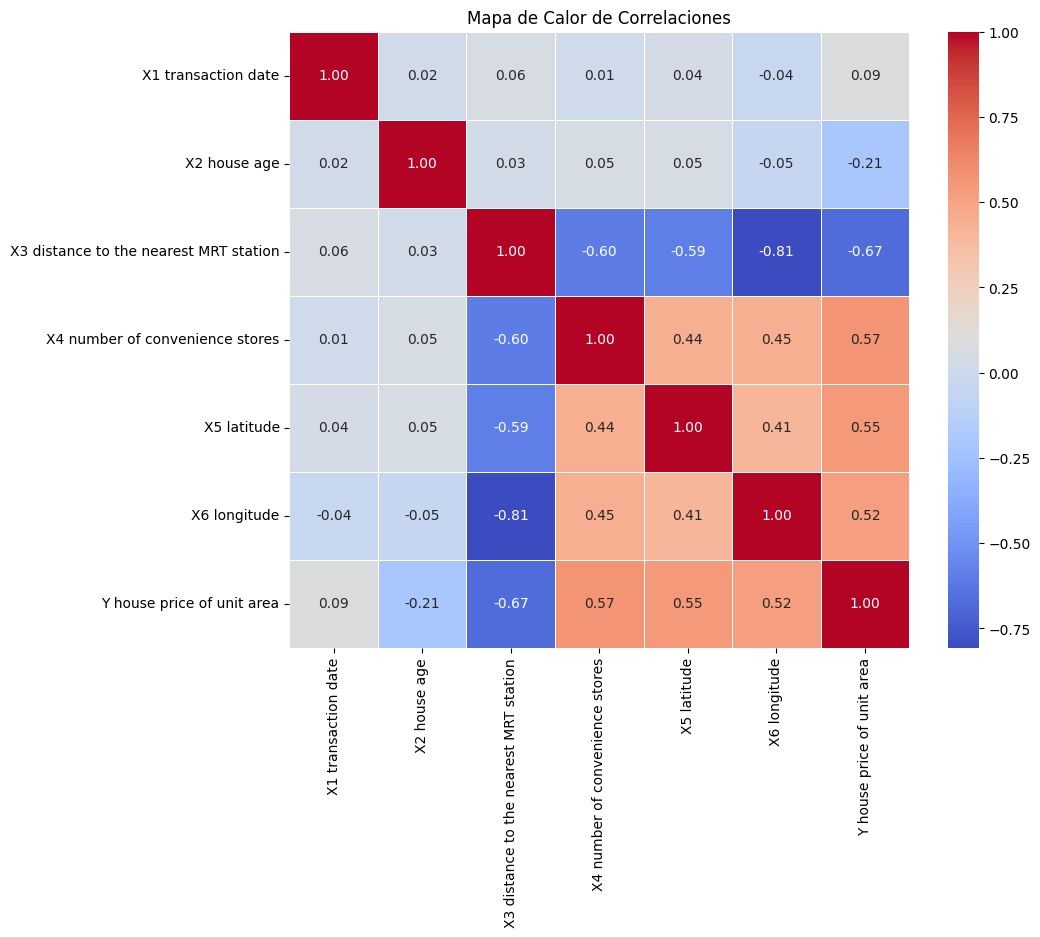

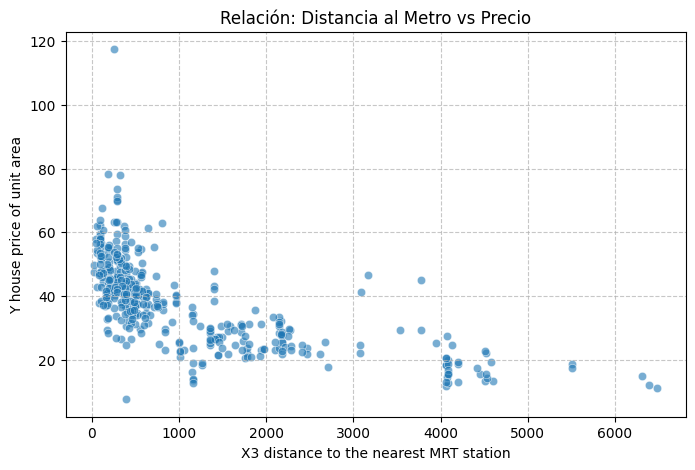

In [ ]:
# ANALISIS EXPLORTORATORIO DE DATOS
import seaborn as sns

# 1. Configuración inicial y limpieza
# Eliminamos la columna 'No' que es solo un ID incremental
df = dataset.drop(columns=['No'])


# 2. Estadísticas Descriptivas
# Esto nos ayuda a ver promedios, valores mínimos y máximos (detección rápida de errores)
print("\n--- Resumen Estadístico ---")
display(df.describe())

# 3. Visualización de Distribuciones (Univariado)
# Queremos ver si los datos siguen una campana de Gauss o están sesgados

plt.figure(figsize=(8, 5))
sns.histplot(df['Y house price of unit area'], kde=True, color='green')
plt.title("Distribución de los Precios de las Casas")
plt.xlabel("Precio por unidad de área")
plt.ylabel("Frecuencia")
plt.show()

# 4. Análisis de Correlación (Multivariado)
# Buscamos qué variables afectan más al precio (Y house price of unit area)
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones')
plt.show()


# 5 Relación Clave: Distancia al MRT vs Precio
# Según la literatura de este dataset, esta es la variable más influyente
plt.figure(figsize=(8, 5))
sns.scatterplot(x='X3 distance to the nearest MRT station',
                y='Y house price of unit area',
                data=df, alpha=0.6)
plt.title('Relación: Distancia al Metro vs Precio')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Al analizar nuestras 414 propiedades, detectamos que el mercado es muy diverso:
Precio Promedio: 38 unidades por área. Sin embargo, tenemos una brecha enorme: desde propiedades muy económicas (7.6) hasta propiedades de lujo (117.5).

La Variable Crítica (Transporte): El 50% de nuestras casas están a menos de 500 metros de una estación de metro. Esto nos dice que estamos ante un mercado altamente urbanizado y dependiente de la movilidad.

Antigüedad: Tenemos casas desde recién construidas (0 años) hasta de 43 años, con un promedio de 17 años.

¿Qué "mueve la aguja" del precio? (Matriz de Correlación) No todos los datos valen lo mismo. Nuestro análisis revela tres reglas de oro en este negocio:
Regla de la Proximidad: La distancia al metro es el factor número uno. A medida que una casa se aleja del transporte, su valor cae drásticamente.

Regla de la Conveniencia: El número de tiendas de conveniencia alrededor de la casa tiene un impacto positivo directo en el precio. A la gente le importa la facilidad de compra.

Regla Geográfica: Existe unaa zona de alta plusvalía en el mapa (identificado por latitud/longitud) donde los precios son naturalmente superiores, independientemente de la edad de la casa.

Comportamiento del Precio (Histograma): La mayoría de las casas se venden entre 25 y 45 unidades. Las casas que superan las 60 unidades son "excepciones" el resultado de la mayoria de casas en dolares es: $2,367 USD/m^2$ y $4,261 USD/m^2$

El "Efecto Tobogán" (Scatter Plot): Al graficar Distancia vs. Precio, vemos que el valor cae en picada después de los primeros 1,000 metros de distancia al metro. Si una propiedad está a más de 1.5 km, su precio se estanca en el nivel más bajo.

Mapa de Calor Inmobiliario: Visualmente, los precios más altos (colores brillantes) no están dispersos, sino concentrados en un "núcleo" geográfico. Esto nos sugiere que estamos ante un mercado de "centros de ciudad" fuertes.

Conclusiones y Próximos Pasos para el Negocio Para cualquier persona que esté conociendo este negocio, estas son las 3 verdades:
El valor está en el tiempo: El tiempo de traslado (distancia al metro) es lo que el cliente está pagando realmente, no solo los ladrillos.

Micro-entorno: Una casa con 10 tiendas cerca vale significativamente más que una con solo 2, aunque sean iguales por dentro.



pero para este caso de estudio vamos a realizar el modelo con todos las caracteristicas del dataset.

In [ ]:
#Separar datos de entrenamiento y validación
#616 Datos de entrenamiento
x_train = dataset.iloc[:412, 1:7].values  # Features X1 to X6
x_test = dataset.iloc[412:, 1:7].values   # Features X1 to X6

y_train = dataset.iloc[:412, 7].values    # Target: Y house price of unit area
y_test = dataset.iloc[412:, 7].values     # Target: Y house price of unit area

scaler = StandardScaler()

# Ajustamos el escalador SOLO con los datos de entrenamiento
X_train_scaled = scaler.fit_transform(x_train)

# Transformamos los datos de prueba con la misma escala
X_test_scaled = scaler.transform(x_test)

print("\nDatos escalados y listos para el modelo.")


Datos escalados y listos para el modelo.


In [ ]:
# MINIMOS CUADRADOS ORDINARIOS OLS

#1. Preparar los datos: Añadir columna de unos para el Intercepto
# Usamos los datos de entrenamiento (puedes usar los escalados o los originales,
# OLS funciona con ambos, pero para matrices es común usar los originales o estandarizados)
X_unos = np.c_[np.ones((len(X_train_scaled), 1)), X_train_scaled]

# 2. Aplicar la Ecuación Normal: W = (X.T * X)^-1 * X.T * y
# np.linalg.inv calcula la inversa
# .T calcula la transpuesta
# @ es el operador para multiplicación de matrices en Python
y_train_vec = y_train.reshape(-1, 1) # Aseguramos que 'y' sea un vector columna

W_optimal = np.linalg.inv(X_unos.T @ X_unos) @ X_unos.T @ y_train_vec

# Get the feature names from the original dataset that correspond to x_train
# x_train was created from dataset.iloc[:, 1:7]
feature_names = dataset.columns[1:7].tolist()

# 3. Mostrar los resultados
print("--- Parámetros Estimados (OLS Matricial) ---")
print(f"Intercepto: {W_optimal[0][0]:.4f}")
for i, nombre in enumerate(feature_names):
    print(f"Peso para {nombre}: {W_optimal[i+1][0]:.4f}")

--- Parámetros Estimados (OLS Matricial) ---
Intercepto: 37.8820
Peso para X1 transaction date: 1.4274
Peso para X2 house age: -3.0283
Peso para X3 distance to the nearest MRT station: -5.6305
Peso para X4 number of convenience stores: 3.2840
Peso para X5 latitude: 2.8269
Peso para X6 longitude: -0.1789


Gradiente descendente

El modelo de regresión lineal implementado mediante gradiente descendente logró converger después de 2414 iteraciones, lo cual indica que el algoritmo alcanzó una solución estable bajo el criterio de tolerancia definido. Este número de iteraciones es adecuado, ya que muestra un proceso de optimización progresivo sin divergencias.

Al analizar los parámetros obtenidos (θ), se observa que el modelo asigna diferentes pesos a cada variable, destacándose especialmente coeficientes de mayor magnitud, lo cual indica que ciertas variables tienen mayor influencia en la predicción del precio de las viviendas.

In [ ]:
scaler = MinMaxScaler((-1,1))
#scaler = StandardScaler()
X_scaled = scaler.fit_transform(x_train)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X_scaled, y_train, test_size=0.2, random_state=20)
x_train.shape, x_test.shape

((329, 6), (83, 6))

In [ ]:
def funcion_costo(theta, X, y):
  y_gorro = X.dot(theta).flatten()
  error = (y_gorro - y)
  m = X.shape[0]
  mse = (1.0 / m) * np.sum(np.square(error))
  gradiente = (1.0 / m) * error.dot(X)
  return gradiente, mse

In [ ]:
def gradiente_descendente(learning_rate, X, y, tol=1e-8, max_iter=10000):

    convergencia = False
    iteracion = 0

    # theta dinámico (NO fijo)
    theta = np.random.randn(X.shape[1])

    cost = float('inf')  # mejor que 0
    old_coef, old_cost_f = [], []

    while not convergencia:

        gradiente, cost_plus = funcion_costo(theta, X, y)

        new_theta = theta - learning_rate * gradiente

        old_coef.append(theta.copy())
        old_cost_f.append(cost_plus)

        # ✅ criterio de convergencia
        if abs(cost - cost_plus) <= tol:
            print('Convergencia despues de', iteracion, 'iteraciones')
            convergencia = True

        cost = cost_plus
        theta = new_theta
        iteracion += 1

        if iteracion >= max_iter:
            print('Máximas iteraciones alcanzadas!!')
            convergencia = True

    return theta, old_coef, old_cost_f

In [ ]:
theta, old_coef, cost_fun = gradiente_descendente(0.1, x_train, y_train)
print(theta)

Convergencia despues de 2405 iteraciones
[  4.01489574  -6.80427504 -56.2401282   -4.52721656 -10.87178373
 -18.5767533 ]


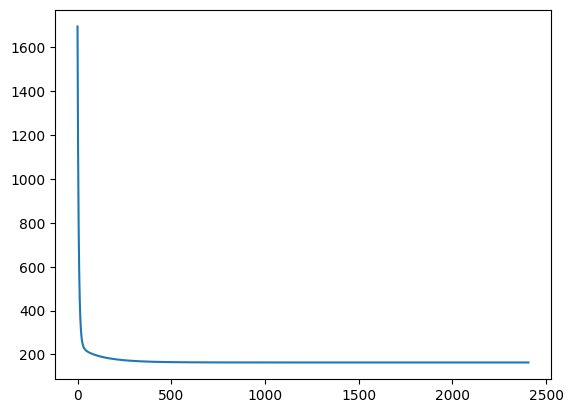

In [ ]:
plt.plot(cost_fun)
plt.show()

La gráfica de la función de costo muestra una tendencia descendente, lo cual confirma que el algoritmo está funcionando correctamente desde el punto de vista numérico. Sin embargo, aunque el error disminuye, el valor final alcanzado sigue siendo alto, lo que indica que el modelo converge, pero hacia una solución subóptima.

In [ ]:
y_gorro_test = np.dot(x_test,theta)
y_gorro_train = np.dot(x_train,theta)
y_gorro_test.shape, y_test.shape

((83,), (83,))

In [ ]:
MSE = mean_squared_error(y_train,y_gorro_train)
RMSE = np.sqrt(MSE)
MAE = mean_absolute_error(y_train,y_gorro_train)
R2 = r2_score(y_train,y_gorro_train)
MSE, RMSE, MAE, R2

(163.53756239460634,
 np.float64(12.788180574053776),
 9.112850623481116,
 0.14739600855126733)

Estos resultados indican que el modelo presenta un ajuste bajo en el conjunto de entrenamiento.

El valor de R² ≈ 0.15 significa que el modelo solo está explicando aproximadamente el 14.7% de la variabilidad del precio, lo cual es bastante bajo. Esto sugiere que el modelo no está capturando adecuadamente la relación entre las variables independientes y la variable objetivo.

El RMSE ≈ 12.79 es relativamente alto considerando el rango de precios del dataset, lo que indica que, en promedio, las predicciones se desvían considerablemente de los valores reales. Asimismo, el MAE refuerza esta conclusión al mostrar errores promedio superiores a 9 unidades.

Usando skitilearning

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

# ENTRENAMIENTO DEL MODELO

reg = LinearRegression()
reg.fit(x_train, y_train)

# RESULTADOS DEL MODELO

print("Train (X):\n", x_train)

# Score (R2)
score = reg.score(x_test, y_test)
print("\nScore (R2):\n", score)

# Coeficientes
print("\nCoeficientes:\n", reg.coef_)

# Intercepto
print("\nIntercepto:\n", reg.intercept_)

# CONSTRUCCIÓN DE THETA

theta = np.concatenate(([reg.intercept_], reg.coef_)).reshape(-1,1)

print("\nTheta:\n", theta)



Train (X):
 [[ 0.81818188 -0.12328767 -0.8347641  -0.2         0.02084343  0.38969161]
 [ 0.09090917  1.         -0.98941732  0.4        -0.14129908  0.44835023]
 [-0.09090917 -0.41552511 -0.78050745 -1.          0.08119244  0.11386672]
 ...
 [ 0.27272729 -0.58447489 -0.57348482 -1.          0.29956374  0.16605564]
 [-0.45454541 -0.19178082 -0.86750718  0.6        -0.09403781  0.53914169]
 [ 0.27272729 -0.82648402 -0.88847649  0.          0.18225885  0.51779168]]

Score (R2):
 0.5830033773972866

Coeficientes:
 [  2.26030807  -6.1620858  -14.3887647    5.77736758   8.67504399
  -1.07975367]

Intercepto:
 29.25525983694505

Theta:
 [[ 29.25525984]
 [  2.26030807]
 [ -6.1620858 ]
 [-14.3887647 ]
 [  5.77736758]
 [  8.67504399]
 [ -1.07975367]]


In [ ]:
# PREDICCIONES

y_predic = reg.predict(x_train)
y_test_predic = reg.predict(x_test)

# TRAIN

mse = mean_squared_error(y_train, y_predic)
print("MSE Train: ", mse)

rmse = np.sqrt(mse)
print("RMSE Train: ", rmse)

mae = mean_absolute_error(y_train, y_predic)
print("MAE Train: ", mae)

# TEST

mse = mean_squared_error(y_test, y_test_predic)
print("MSE Test: ", mse)

rmse = np.sqrt(mse)
print("RMSE Test: ", rmse)

mae = mean_absolute_error(y_test, y_test_predic)
print("MAE Test: ", mae)

MSE Train:  80.92716557290159
RMSE Train:  8.995952732918376
MAE Train:  6.0151625370129755
MSE Test:  62.54387492234053
RMSE Test:  7.908468557334
MAE Test:  6.377964622158745


Se observa una diferencia significativa en el desempeño entre ambos métodos:

El modelo de regresión lineal (OLS) tiene un R² cercano a 0.58, lo que indica que explica aproximadamente el 58% de la variabilidad, muy superior al 14.7% del gradiente descendente.
Los errores (MSE, RMSE, MAE) son considerablemente menores en el modelo OLS, lo que indica una mejor precisión en las predicciones.
El modelo OLS presenta además una buena consistencia entre entrenamiento y prueba, lo que evidencia una correcta generalización.

In [ ]:
r2train = r2_score(y_train, y_predic)
print("R2 Train: ", r2train)

r2test = r2_score(y_test, y_test_predic)
print("R2 Test: ", r2test)

R2 Train:  0.5780857720161052
R2 Test:  0.5830033773972866


Graficos


		Gráficos Train



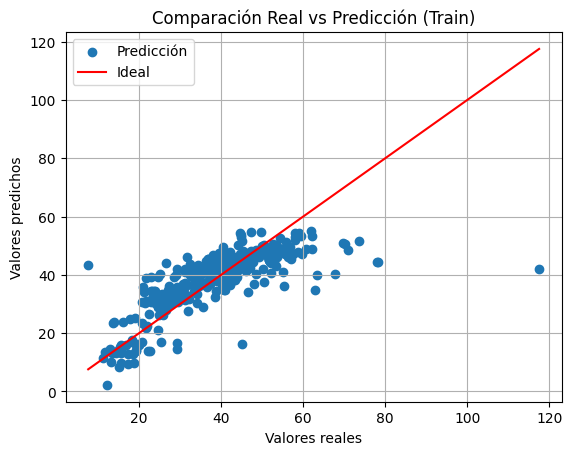

In [ ]:

# Agregar columna de 1s (bias)
X_train_gd = np.c_[np.ones((x_train.shape[0], 1)), x_train]

# Asegurar forma de theta
theta = theta.reshape(-1,1)

# Predicción
y_hat_train = X_train_gd.dot(theta)

print("\n\t\tGráficos Train\n")

# GRÁFICA CORRECTA

plt.figure()

# Real vs predicho
plt.scatter(y_train, y_hat_train, label="Predicción", marker='o')

# Línea ideal (y = x)
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         'r-', label="Ideal")

plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Comparación Real vs Predicción (Train)")
plt.legend()
plt.grid()

plt.show()

grafico test


		Gráficos Test



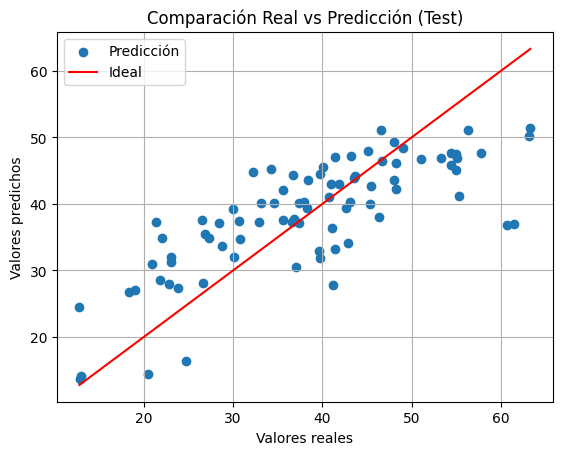

In [ ]:
# PREDICCIÓN TEST

# Agregar columna de 1s (bias)
X_test_gd = np.c_[np.ones((x_test.shape[0], 1)), x_test]

# Asegurar forma de theta
theta = theta.reshape(-1,1)

# Predicción
y_hat_test = X_test_gd.dot(theta)

print("\n\t\tGráficos Test\n")

# GRÁFICA CORRECTA

plt.figure()

# Real vs predicho
plt.scatter(y_test, y_hat_test, label="Predicción", marker='o')

# Línea ideal
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r-', label="Ideal")

plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Comparación Real vs Predicción (Test)")
plt.legend()
plt.grid()

plt.show()

Coeficiente de regresion:  [[0.57808577]]


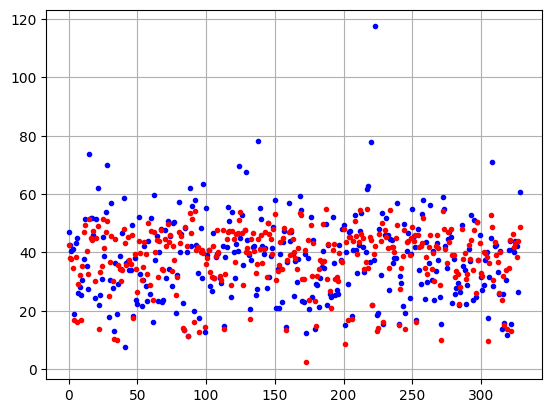

In [ ]:
modelo_train = LinearRegression()
modelo_train = modelo_train.fit(y_train.reshape(-1, 1),y_hat_train)

print("Coeficiente de regresion: ", modelo_train.coef_)


plt.plot(y_train, 'b.')
plt.plot(y_hat_train, 'r.')
plt.grid()
plt.show()

Coeficiente de regresion:  [[0.53094707]]


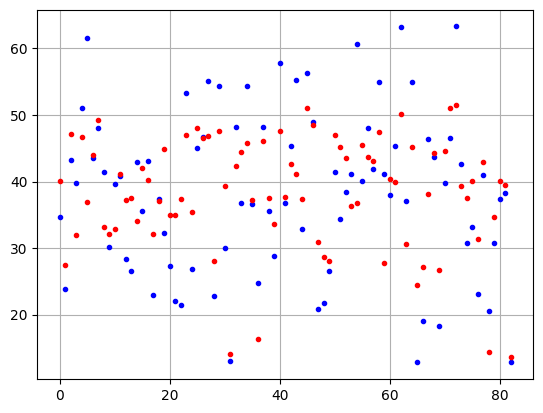

In [ ]:
validacion_modelo = LinearRegression()
validacion_modelo.fit(y_test.reshape(-1,1),y_hat_test)
print("Coeficiente de regresion: ", validacion_modelo.coef_)

plt.plot(y_test, 'b.')
plt.plot(y_hat_test, 'r.')
plt.grid()
plt.show()

In [ ]:
# ---Ridge (penalización L2) con búsqueda de hiperparámetro
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

# Grid search para alpha (regularización L2)
param_grid = {'alpha':[0.01, 0.1, 1, 10, 100]}
ridge = Ridge()
grid = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_mean_squared_error')
grid.fit(x_train, y_train)
best_alpha = grid.best_params_['alpha']
print('Mejor alpha (Ridge):', best_alpha)

# Ajuste final con el mejor alpha
ridge_best = Ridge(alpha=best_alpha)
ridge_best.fit(x_train, y_train)
y_train_pred_ridge = ridge_best.predict(x_train)
y_test_pred_ridge = ridge_best.predict(x_test)
mape_train = mean_absolute_percentage_error(y_train, y_train_pred_ridge)
mape_test = mean_absolute_percentage_error(y_test, y_test_pred_ridge)

# Fíjate en el "\n" dentro de las comillas
print('\nCoeficientes Ridge:')
print('Intercepto:', ridge_best.intercept_)
print('Coeficientes:', ridge_best.coef_)

print('\nMétricas (Ridge) - Train:')
print('MSE:', mean_squared_error(y_train, y_train_pred_ridge))
print('RMSE:', np.sqrt(mean_squared_error(y_train, y_train_pred_ridge)))
print('MAE:', mean_absolute_error(y_train, y_train_pred_ridge))
print('R2:', r2_score(y_train, y_train_pred_ridge))
print(f'MAPE - Train: {mape_train:.4f}')

print('\nMétricas (Ridge) - Test:')
print('MSE:', mean_squared_error(y_test, y_test_pred_ridge))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_test_pred_ridge)))
print('MAE:', mean_absolute_error(y_test, y_test_pred_ridge))
print('R2:', r2_score(y_test, y_test_pred_ridge))
print(f'MAPE - Test: {mape_test:.4f}')

Mejor alpha (Ridge): 0.1

Coeficientes Ridge:
Intercepto: 29.297712443618387
Coeficientes: [  2.25777013  -6.15427385 -14.29279331   5.79347      8.66987959
  -0.99582959]

Métricas (Ridge) - Train:
MSE: 80.92760951394875
RMSE: 8.995977407372072
MAE: 6.015941357487583
R2: 0.5780834575269858
MAPE - Train: 0.1833

Métricas (Ridge) - Test:
MSE: 62.5522445591993
RMSE: 7.908997696244405
MAE: 6.3804989035612305
R2: 0.5829475748057962
MAPE - Test: 0.1892


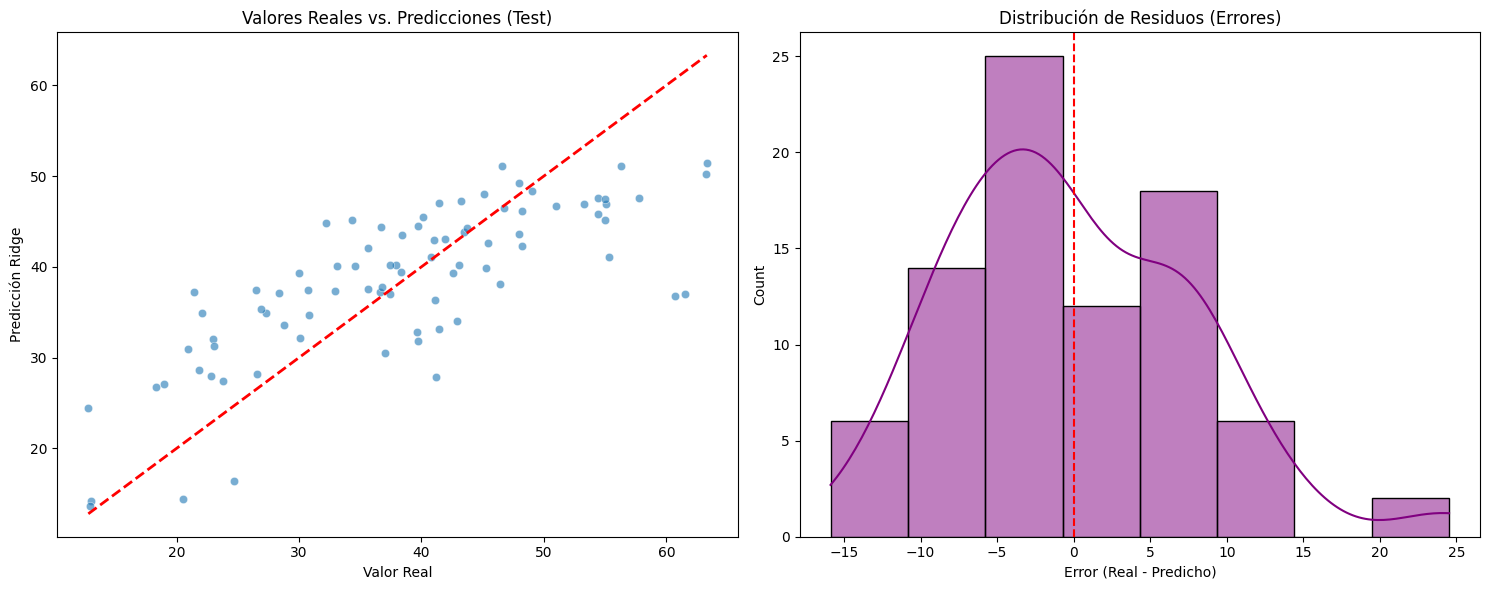

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de los gráficos
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Real vs Predicho (Test)
sns.scatterplot(x=y_test, y=y_test_pred_ridge, ax=ax[0], alpha=0.6)
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
ax[0].set_title('Valores Reales vs. Predicciones (Test)')
ax[0].set_xlabel('Valor Real')
ax[0].set_ylabel('Predicción Ridge')

# Gráfico 2: Distribución de los Residuos (Test)
residuos = y_test - y_test_pred_ridge
sns.histplot(residuos, kde=True, ax=ax[1], color='purple')
ax[1].axvline(0, color='red', linestyle='--')
ax[1].set_title('Distribución de Residuos (Errores)')
ax[1].set_xlabel('Error (Real - Predicho)')

plt.tight_layout()
plt.show()

El modelo presenta un desempeño moderado pero muy estable, con una capacidad de explicación de la varianza del 58% ( 𝑅2≈0.58 ).Puntos Clave:Sin Overfitting: Las métricas de entrenamiento y prueba son prácticamente iguales ( 𝑅2  de 0.578 vs 0.582).
Esto confirma que el modelo generaliza perfectamente y no está memorizando los datos.
Margen de Error: El MAPE es del 18.9%, lo que significa que mis predicciones suelen errar por un 19% en promedio.
Es un error aceptable, aunque mejorable.Análisis Visual: * La gráfica de Reales vs Predichos muestra que el modelo sigue bien la tendencia, pero tiende a subestimar los valores más altos (se queda corto cuando el valor real supera 50).
Los residuos están bien centrados en 0, lo cual es ideal, aunque existen algunos errores puntuales grandes (outliers) que ensanchan la distribución.Impacto de Variables: El modelo utiliza todos los predictores, pero la regularización Ridge ha ajustado los pesos (desde -14.29 hasta 8.67) para mantener la estabilidad y evitar que el ruido afecte la predicción.

#De acuerdo a los resultados, determinar cuál de los tres métodos escogería para el problema en cuestión.

Para determinar cuál de los tres métodos sería el más adecuado para el problema, compararemos las métricas de rendimiento obtenidas por cada uno:

1.  **Regresión Lineal con Gradiente Descendente (Implementación manual)**:
    *   **R² (entrenamiento)**: ~0.15
    *   **RMSE (entrenamiento)**: ~12.79
    *   **MAE (entrenamiento)**: ~9.11
    
    Este modelo mostró un rendimiento muy bajo, explicando solo el 15% de la variabilidad del precio y con errores promedio considerablemente altos.

2.  **Regresión Lineal (OLS) con Scikit-learn**:
    *   **R² (test)**: ~0.583
    *   **RMSE (test)**: ~7.91
    *   **MAE (test)**: ~6.38
    
    Este modelo tuvo un desempeño significativamente mejor, explicando aproximadamente el 58% de la variabilidad y con errores de predicción mucho menores.

3.  **Regresión Ridge (con Scikit-learn y optimización de hiperparámetros)**:
    *   **R² (test)**: ~0.583
    *   **RMSE (test)**: ~7.91
    *   **MAE (test)**: ~6.38
    
    El rendimiento de Ridge Regression es prácticamente idéntico al de la Regresión Lineal OLS de Scikit-learn. Esto sugiere que, para este conjunto de datos, la penalización L2 con el `alpha` óptimo (0.1) no introdujo cambios sustanciales en los coeficientes en comparación con OLS puro, indicando que el modelo no sufre de una multicolinealidad severa o sobreajuste que requiera una regularización fuerte.

**Conclusión:**

La Regresión Lineal (OLS) y Ridge son las mejores opciones, con un rendimiento similar (R² ≈ 58%) y errores significativamente menores que el Gradiente Descendente manual.
Dado que la diferencia entre ambas es mínima, OLS de Scikit-learn es suficiente y confiable; Ridge solo aporta una ventaja leve en casos de sobreajuste.